# 📊Customer Churn Predictive Modelling
> **Project Overview:** This notebook details the end-to-end development of a machine learning pipeline designed to proactively identify churning customers. By navigating the classic precision-recall trade-off and leveraging Explainable AI (XAI), we translate raw algorithmic probabilities into actionable retention strategies.
----

## Objective and Scope of this report

>To aid in maximizing customer retention and intercept customers at-risk of churn. We build and optimize a model for predicting customer churn that maximizes **Recall** minimizing false-negatives.

## 2. Exploratory Data Analysis & Preprocessing


In [1]:
import pandas as pd
import numpy as np
from IPython.core.pylabtools import figsize
from scipy.stats import contingency
from seaborn import categorical
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df= pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(df.columns)
df.info()
df.isna().sum()

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   Onli

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

### **Target Imbalance:**

Initial exploration reveals a ~27% churn rate vs. a ~73% retention rate, indicating a severe class imbalance.

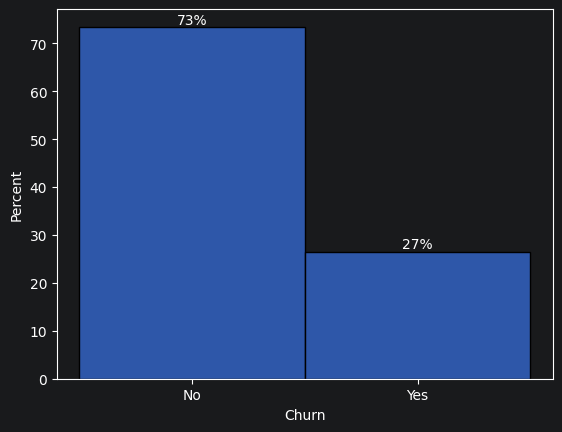

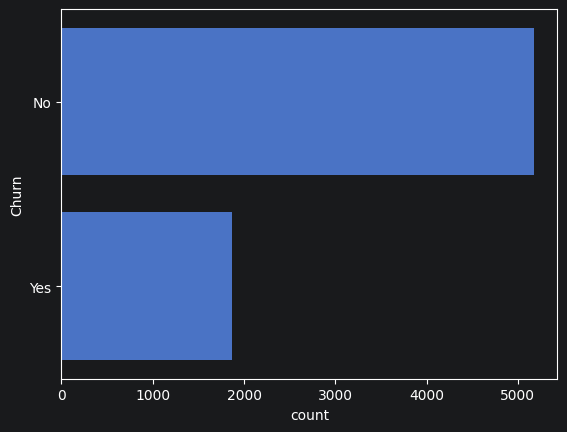

In [6]:
ax=sns.histplot(df["Churn"], stat="percent")
plt.bar_label(ax.containers[0], fmt= "%.0f%%")
plt.show()
sns.countplot(df["Churn"])
plt.show()

## Statistical Analysis

Using $\chi$<sup>2</sup> test of independence to determine dependant features


In [7]:
from scipy.stats import chi2_contingency

categorical_features = [
    "gender", "SeniorCitizen", "Partner",
    "Dependents","PhoneService", "MultipleLines",
    "InternetService", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]
churn = df["Churn"]
selected_features = []
independent_features = []
for cat in categorical_features:
    print(f"-------- vs. {cat}")
    contingency_table = pd.crosstab(df[cat], churn)
    chi2, p, dof, expected= chi2_contingency(contingency_table)
    result = "significant ✅" if p < 0.05 else "not significant❎"
    print(f"p-value: {p:.5f} \t result: {result}")
    if result == "significant ✅":
        selected_features.append(cat)
    else:
        independent_features.append(cat)
print(selected_features)

-------- vs. gender
p-value: 0.48658 	 result: not significant❎
-------- vs. SeniorCitizen
p-value: 0.00000 	 result: significant ✅
-------- vs. Partner
p-value: 0.00000 	 result: significant ✅
-------- vs. Dependents
p-value: 0.00000 	 result: significant ✅
-------- vs. PhoneService
p-value: 0.33878 	 result: not significant❎
-------- vs. MultipleLines
p-value: 0.00346 	 result: significant ✅
-------- vs. InternetService
p-value: 0.00000 	 result: significant ✅
-------- vs. OnlineBackup
p-value: 0.00000 	 result: significant ✅
-------- vs. DeviceProtection
p-value: 0.00000 	 result: significant ✅
-------- vs. TechSupport
p-value: 0.00000 	 result: significant ✅
-------- vs. StreamingTV
p-value: 0.00000 	 result: significant ✅
-------- vs. StreamingMovies
p-value: 0.00000 	 result: significant ✅
-------- vs. Contract
p-value: 0.00000 	 result: significant ✅
-------- vs. PaperlessBilling
p-value: 0.00000 	 result: significant ✅
-------- vs. PaymentMethod
p-value: 0.00000 	 result: signi

Dropping independent features

In [8]:

df.drop(independent_features, axis='columns', inplace=True)


check for two sample t_test assumptions

<Axes: xlabel='tenure', ylabel='Count'>

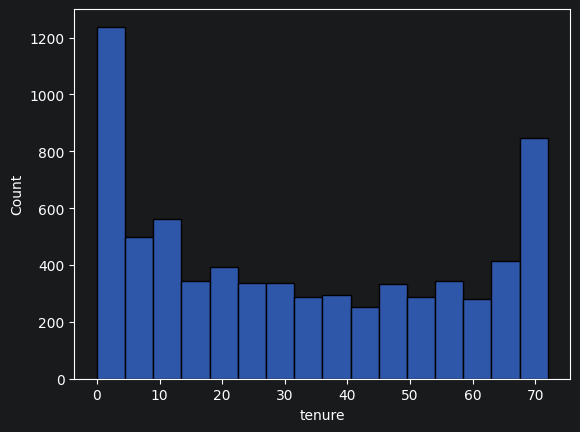

In [9]:


sns.histplot(df["tenure"], stat="count")

Since the `tenure` is normally distributed, we fall back to `mannwhitneyu`

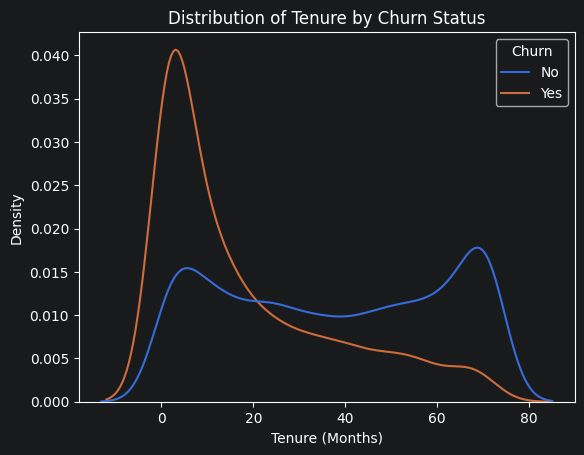

In [10]:

churned_tenure = df[churn == "Yes"]["tenure"]
stayed_tenure = df[churn == "No"]["tenure"]
sns.kdeplot(df,x="tenure",hue="Churn", common_norm=False ,)
plt.title("Distribution of Tenure by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Density")
plt.show()

In [11]:
from scipy.stats import mannwhitneyu
u_stat, p = mannwhitneyu(churned_tenure, stayed_tenure)
result = "significant" if p<0.05 else "not significant"
print(f"u-statistic: {u_stat: .5f} \t p-value: {p:.5f} \t result: {result}")

u-statistic:  2515538.00000 	 p-value: 0.00000 	 result: significant


In [12]:
churned_mon_charges = df[churn == "Yes"]["MonthlyCharges"]
stayed_mon_charges = df[churn == "No"]["MonthlyCharges"]
u_stat, p = mannwhitneyu(churned_mon_charges, stayed_mon_charges)
result = "significant" if p<0.05 else "not significant"
print(f"u-statistic: {u_stat: .5f} \t p-value: {p:.5f} \t result: {result}")

u-statistic:  6003125.50000 	 p-value: 0.00000 	 result: significant


<Axes: >

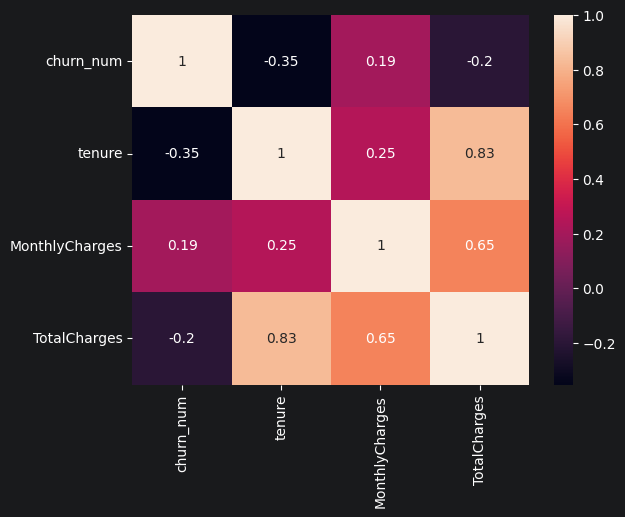

In [13]:
df["churn_num"] = df["Churn"].map({"Yes":1, "No":0})

numerical_features = ["churn_num", "tenure", "MonthlyCharges", "TotalCharges"]

corr_matrix= df[numerical_features].corr()
sns.heatmap(corr_matrix, annot=True,)

In [14]:
selected_features.extend(["churn_num", "tenure", "MonthlyCharges", ])
selected_features

['SeniorCitizen',
 'Partner',
 'Dependents',
 'MultipleLines',
 'InternetService',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'churn_num',
 'tenure',
 'MonthlyCharges']

In [15]:
print(df[selected_features].columns)

Index(['SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines',
       'InternetService', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'churn_num', 'tenure', 'MonthlyCharges'],
      dtype='str')


**Preprocessing Pipeline:** One-hot ncoding categorical features (e.g., `Contract types`, `Internet Service`) and preparing feature matrices ($X$) and target vectors ($y$).

In [16]:
df_enc= pd.get_dummies(df[selected_features], columns=['SeniorCitizen', 'Partner', 'Dependents',
                                    'MultipleLines','InternetService', 'OnlineBackup',
                                    'DeviceProtection', 'TechSupport','StreamingTV',
                                    'StreamingMovies', 'Contract', 'PaperlessBilling',
                                    'PaymentMethod', 'churn_num',],
                       drop_first= True)
#df_enc.drop(columns=["customerID","onlineSecurity"], axis='columns', inplace=True)
df_enc.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 7043 non-null   int64  
 1   MonthlyCharges                         7043 non-null   float64
 2   SeniorCitizen_1                        7043 non-null   bool   
 3   Partner_Yes                            7043 non-null   bool   
 4   Dependents_Yes                         7043 non-null   bool   
 5   MultipleLines_No phone service         7043 non-null   bool   
 6   MultipleLines_Yes                      7043 non-null   bool   
 7   InternetService_Fiber optic            7043 non-null   bool   
 8   InternetService_No                     7043 non-null   bool   
 9   OnlineBackup_No internet service       7043 non-null   bool   
 10  OnlineBackup_Yes                       7043 non-null   bool   
 11  DeviceProtectio

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_enc["MonthlyChargesScaled"] = scaler.fit_transform(df_enc[["MonthlyCharges"]])
print(df_enc.head())

   tenure  MonthlyCharges  SeniorCitizen_1  Partner_Yes  Dependents_Yes  \
0       1           29.85            False         True           False   
1      34           56.95            False        False           False   
2       2           53.85            False        False           False   
3      45           42.30            False        False           False   
4       2           70.70            False        False           False   

   MultipleLines_No phone service  MultipleLines_Yes  \
0                            True              False   
1                           False              False   
2                           False              False   
3                            True              False   
4                           False              False   

   InternetService_Fiber optic  InternetService_No  \
0                        False               False   
1                        False               False   
2                        False               False

## Logistic Regression
Using `LogisticRegression` as a baseline model

              precision    recall  f1-score   support

       False       0.85      0.90      0.88      1029
        True       0.68      0.58      0.63       380

    accuracy                           0.81      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



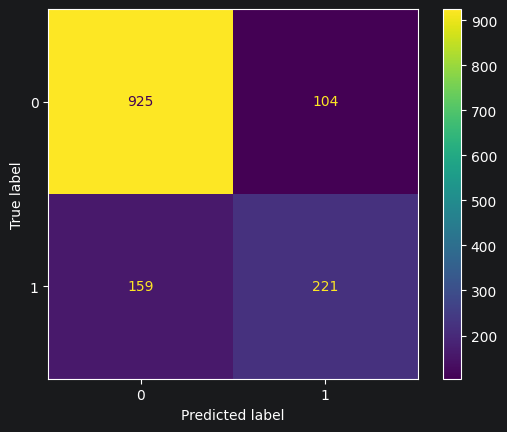

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
RANDOM_STATE_SEED= 67
X = df_enc.drop(columns=["churn_num_1"], axis='columns', inplace=False)
y = df_enc["churn_num_1"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE_SEED)

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)
y_pred = (model.predict(X_test))
#p_y = model.predict_proba(X_test)

print(classification_report(y_test, y_pred))
confusion_matrix= confusion_matrix(y_test, y_pred)

disp= ConfusionMatrixDisplay(confusion_matrix=confusion_matrix,)
disp.plot()

([<matplotlib.axis.XTick at 0x21a51a5a210>,
 [Text(0.0, 0, '0.0'),
  Text(0.1, 0, '0.1'),
  Text(0.2, 0, '0.2'),
  Text(0.30000000000000004, 0, '0.3'),
  Text(0.4, 0, '0.4'),
  Text(0.5, 0, '0.5'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.7000000000000001, 0, '0.7'),
  Text(0.8, 0, '0.8'),
  Text(0.9, 0, '0.9'),
  Text(1.0, 0, '1.0')])

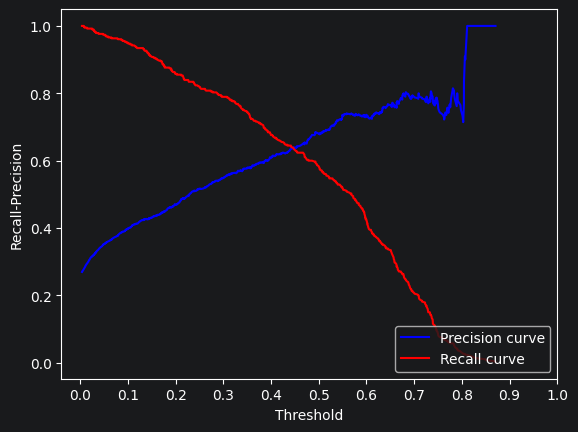

In [19]:
from sklearn.metrics import precision_recall_curve
thresholds = [0.5, 0.45, 0.4, 0.35, 0.3]
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_custom = y_pred > y_proba
precision, recall, thresholds= precision_recall_curve(y_test, y_proba)
plt.plot(thresholds, precision[:-1], label="Precision curve", color="blue")
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.plot(thresholds, recall[:-1], label="Recall curve", color="red")
plt.xlabel("Threshold")
plt.ylabel("Recall-Precision")
plt.legend(loc="lower right")
plt.xticks(np.arange(0, 1.1, 0.1))

In [20]:
logistic_model = LogisticRegression(max_iter=500, random_state=RANDOM_STATE_SEED)
logistic_model.fit(X_train, y_train)
logistic_pred = logistic_model.predict(X_test)


A good threshold is typical left of the intersection of the 2 lines `threshold = 0.3` as we optimize for **Recall** for a better true-positive rate or a higher probability of detection of at-risk churning customers.

> a drop of $\sim 2\%$ in accuracy from 0.5 to 0.3 `threshold` for a drastic increase of $\sim 19\% $ in Recall is already good enough no need to go for a lower `threshold`

              precision    recall  f1-score   support

       False       0.91      0.76      0.83      1029
        True       0.55      0.79      0.65       380

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409



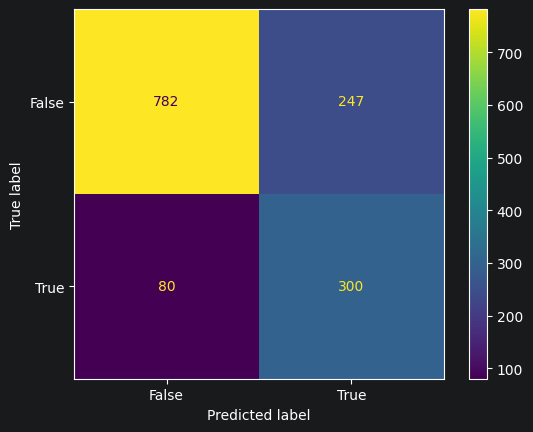

In [21]:
logistic_model = LogisticRegression(max_iter=500, random_state=RANDOM_STATE_SEED)
logistic_model.fit(X_train, y_train)
logistic_pred = logistic_model.predict(X_test)
threshold = 0.3

logistic_proba = logistic_model.predict_proba(X_test)[:,1]
logistic_pred_custom = (logistic_proba >= threshold)
#logistic_cm1 =
ConfusionMatrixDisplay.from_predictions(y_test, logistic_pred_custom)

report= classification_report(y_test, logistic_pred_custom)
print(report)


## 4. Model Optimization: Handling Class Imbalance
To force XGBoost to care about the minority class, we dynamically calculate the class weight ratio ($C$) using only the training distribution:

$$C = \frac{\sum (y_{train} == 0)}{\sum (y_{train} == 1)}$$

By passing this to `scale_pos_weight`, we penalize misclassifications on the churn class.
* **Result:** Accuracy experiences a minor 1.6% "tax" (dropping to 76.4%), while **Recall spikes to 71.1%**, successfully capturing nearly 3 out of 4 churning customers.

---

In [23]:
import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, recall_score

C = (y_train==0).sum()/(y_train==1).sum()

xgboost_model = XGBClassifier(scale_pos_weight=C, random_state=RANDOM_STATE_SEED)
xgboost_model.fit(X_train, y_train)

y_pred = xgboost_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.7672107877927609
Recall: 0.7131578947368421


## 5. Threshold Analysis: Precision-Recall Curve
Using the Precision-Recall curve, we map the entire operational sandbox. With an **Average Precision (AP) of 0.64**, we strategically choose our decision threshold to balance aggressive customer acquisition/retention loops against the cost of marketing discount dilution.

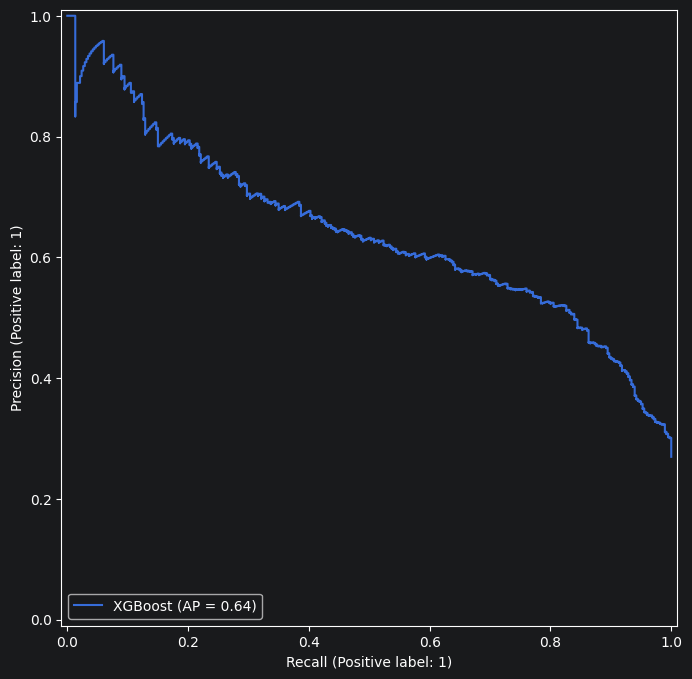

In [24]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(10,8))

PrecisionRecallDisplay.from_estimator(
    xgboost_model,X_test, y_test, ax=ax,name="XGBoost"
)

## 6. Model Interpretability via SHAP
we deploy **SHAP (SHapley Additive exPlanations)** To uncover the most driving feature behind the model's choices.

C:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


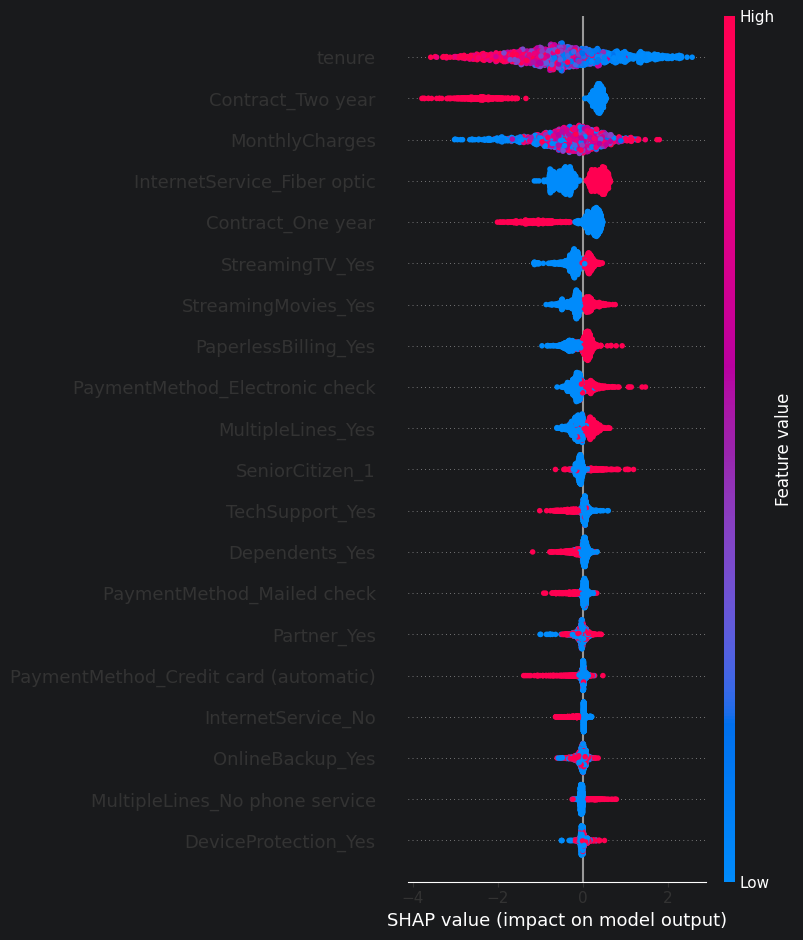

In [25]:
import shap

explainer = shap.TreeExplainer(xgboost_model)

shap_values = explainer(X_test)
ax, fig = plt.subplots(figsize=(10,8))
shap.summary_plot(shap_values, X_test, )